In [8]:
import pandas as pd

from pycaret.regression import *
from pycaret.classification import *

### Решение задачи регрессии с использованием `pycaret`

In [2]:
regression_data = pd.read_csv("../data/diamonds_filtered.csv")
y_regression = regression_data['price']
x_regression = regression_data.drop('price', axis=1)

In [3]:
setup(
    data=regression_data,
    target='price',
    session_id='81',
    train_size=0.8,
    preprocess=True,
    normalize=True, 
    normalize_method='zscore',
    low_variance_threshold=0.1,
    data_split_shuffle=True
)

,Description,Value
0,Session id,81
1,Target,price
2,Target type,Regression
3,Original data shape,"(48488, 8)"
4,Transformed data shape,"(48488, 8)"
5,Transformed train set shape,"(38790, 8)"
6,Transformed test set shape,"(9698, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


In [4]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [5]:
best_model_reg = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,242.6063,209750.3160,457.6254,0.9837,0.0965,0.0736,0.4870
lightgbm,Light Gradient Boosting Machine,249.5779,217408.8735,465.8131,0.9831,0.1017,0.0783,0.2730
rf,Random Forest Regressor,252.4571,238348.6985,487.8306,0.9815,0.0987,0.0741,0.7710
et,Extra Trees Regressor,254.8533,244915.6524,494.4562,0.9810,0.1019,0.0754,0.5930
gbr,Gradient Boosting Regressor,298.9724,286193.2370,534.6448,0.9778,0.1366,0.0999,0.2100
dt,Decision Tree Regressor,331.3020,425945.7223,651.8582,0.9669,0.1324,0.0944,0.0180
knn,K Neighbors Regressor,369.8342,442074.6063,664.1533,0.9657,0.1430,0.1117,0.0190
br,Bayesian Ridge,730.4030,1150332.6933,1072.0595,0.9108,0.6298,0.4024,0.0090
llar,Lasso Least Angle Regression,730.9207,1150463.3330,1072.1174,0.9108,0.6352,0.4030,0.0070
lar,Least Angle Regression,730.3674,1150306.5962,1072.0472,0.9108,0.6299,0.4024,0.0070


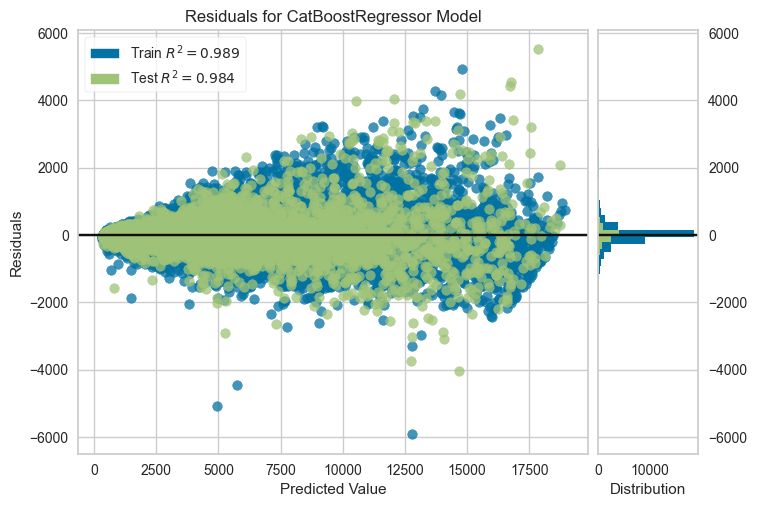

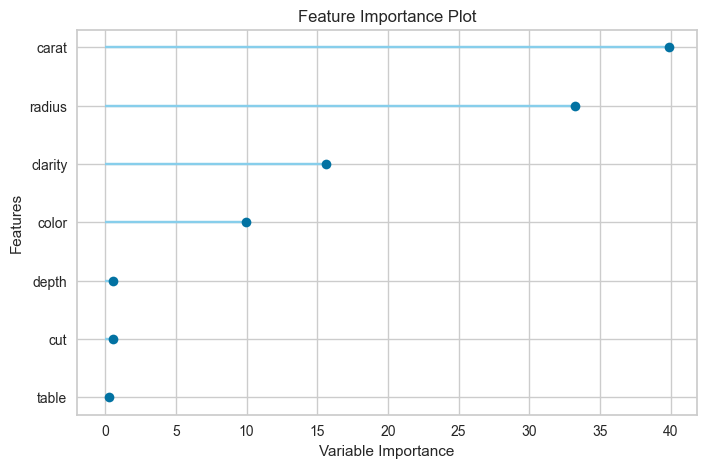

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [6]:
plot_model(best_model_reg, plot='residuals')

plot_model(best_model_reg, plot='feature')

evaluate_model(best_model_reg)

In [7]:
holdout_predictions_reg = predict_model(best_model_reg)
holdout_predictions_reg.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,242.2619,202212.0222,449.6799,0.9841,0.0965,0.0741


,carat,cut,color,clarity,depth,table,radius,price,prediction_label
5560,1.01,4,5,2,61.799999,59,3.205,4008,4232.430404
48458,0.70,3,6,3,62.700001,59,2.815,2753,2419.916676
19263,1.70,3,1,3,63.200001,57,3.815,9253,8177.005283
43240,0.54,4,6,5,60.299999,58,2.630,1939,1917.373020
27517,0.32,3,7,3,63.299999,57,2.190,756,664.648516


### Решение задачи классификации с использованием `pycaret`

In [10]:
classification_data = pd.read_csv("../data/credit_card_fraud_filtered.csv")

In [ ]:
s = setup(
    data=classification_data,
    target='fraud',          
    session_id=81,
    train_size=0.8,
    preprocess=True,
    normalize=True,
    fix_imbalance=True,       
    fix_imbalance_method='smoteenn'
)

,Description,Value
0,Session id,81
1,Target,fraud
2,Target type,Binary
3,Original data shape,"(884794, 9)"
4,Transformed data shape,"(1493254, 9)"
5,Transformed train set shape,"(1316295, 9)"
6,Transformed test set shape,"(176959, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [12]:
best_model_clf = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,1.0000,1.0000,1.0000,0.9994,0.9997,0.9996,0.9996,2.7430
rf,Random Forest Classifier,0.9999,1.0000,1.0000,0.9989,0.9995,0.9994,0.9994,15.1070
ada,Ada Boost Classifier,0.9998,1.0000,1.0000,0.9973,0.9986,0.9985,0.9985,7.3670
gbc,Gradient Boosting Classifier,0.9998,1.0000,0.9999,0.9970,0.9985,0.9984,0.9984,25.5780
et,Extra Trees Classifier,0.9993,1.0000,0.9999,0.9898,0.9948,0.9945,0.9945,7.0450
lightgbm,Light Gradient Boosting Machine,0.9983,0.9999,0.9961,0.9777,0.9867,0.9858,0.9859,3.1530
catboost,CatBoost Classifier,0.9976,1.0000,0.9992,0.9643,0.9814,0.9801,0.9803,23.5840
knn,K Neighbors Classifier,0.9968,0.9992,0.9996,0.9521,0.9753,0.9735,0.9739,3.7210
lr,Logistic Regression,0.9493,0.9893,0.9781,0.5598,0.7121,0.6865,0.7188,2.9210
svm,SVM - Linear Kernel,0.9454,0.9884,0.9850,0.5404,0.6979,0.6706,0.7073,2.5600


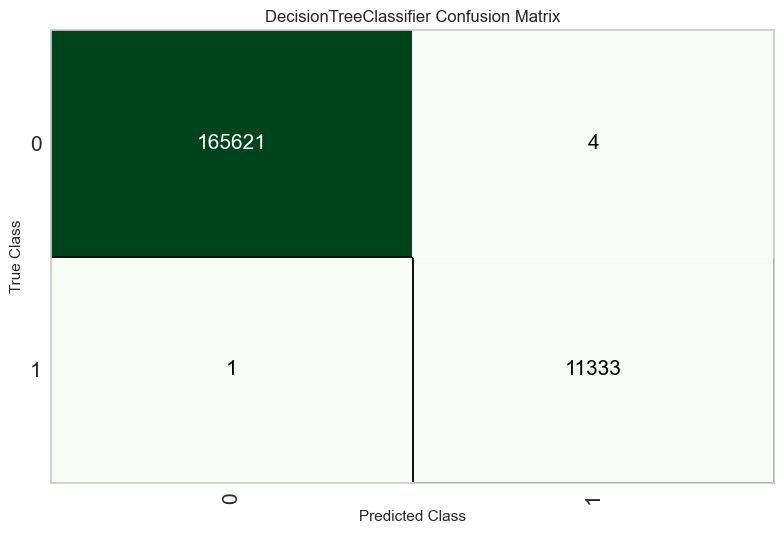

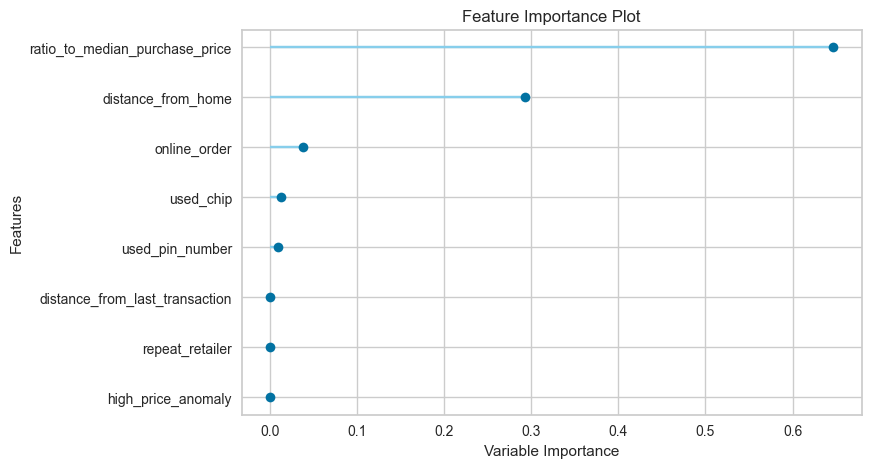

In [14]:
plot_model(best_model_clf, plot='confusion_matrix')

plot_model(best_model_clf, plot='feature')

In [15]:
predictions = predict_model(best_model_clf)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,1.0000,0.9999,0.9999,0.9996,0.9998,0.9998,0.9998


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly,fraud,prediction_label,prediction_score
111835,1.114108,14.357532,0.682439,0,0,0,1,0,0,0,1.0
147278,113.259636,0.324457,1.425471,1,0,0,1,0,1,1,1.0
372115,15.367021,0.594931,2.020604,1,0,0,1,0,0,0,1.0
53390,34.599174,1.900328,9.047384,1,0,0,1,1,1,1,1.0
876874,36.935543,0.423437,0.454763,1,0,1,1,0,0,0,1.0
